2026-07-29 생성형AI 활용을 위한 머신러닝&딥러닝

# 기초통계

In [ ]:
# IQR = Q3 - Q1
# 이상치 범위 : Q1 - 1.5 * IQR ~ Q3 + 1.5 * IQR

In [2]:
import pandas as pd

data = [10, 15, 20, 10, 30, 40]
data_series = pd.Series(data)

print(data_series.mean())
print(data_series.median())
print(data_series.mode()[0])

20.833333333333332
17.5
10


In [4]:
data = {
    'score' : [55, 60, 65, 70, 75, 80, 85, 90, 95]
}

df = pd.DataFrame(data)

print(type(df))
var_val = df['score'].var()     # 분산
print(var_val)

print(df['score'].std())        # 표준편차


q1_val = df['score'].quantile(0.25)  # 1사분위수
q2_val = df['score'].quantile(0.5)   # 2사분위수
q3_val = df['score'].quantile(0.75)  # 3사분위수
q4_val = df['score'].max()           # 4사분위수

print(q1_val)
print(q2_val)
print(q3_val)
print(q4_val)

<class 'pandas.DataFrame'>
187.5
13.693063937629153
65.0
75.0
85.0
95


In [6]:
print('IQR: ', q3_val - q1_val)
print('up', q3_val + 1.5 * (q3_val - q1_val))
print('down', q1_val - 1.5 * (q3_val - q1_val))

IQR:  20.0
up 115.0
down 35.0


# 시각화

In [7]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 48.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 44.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 49.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# - 부호 깨짐 방지
plt.rc('axes', unicode_minus=False)

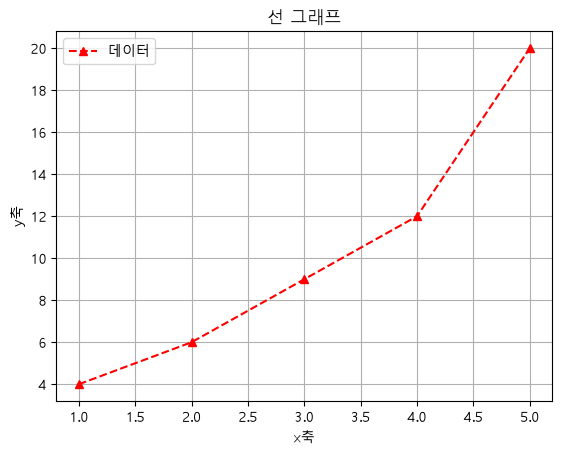

In [44]:
x = [1, 2, 3, 4, 5]
y = [4, 6, 9, 12, 20]

plt.plot(
    x, y,
    color='red',
    marker='^',
    linestyle='--',
    label='데이터'
    )

plt.title('선 그래프')
plt.xlabel('x축')
plt.ylabel('y축')
plt.grid()
plt.legend()

<BarContainer object of 5 artists>

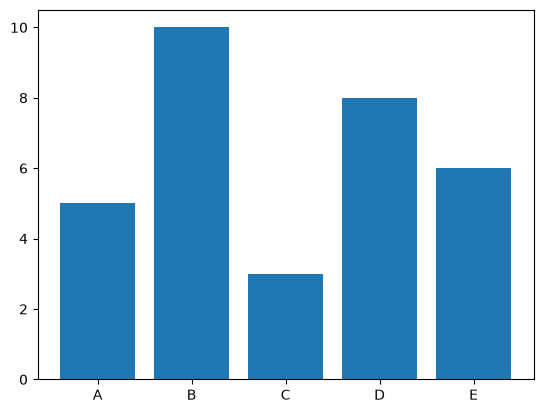

In [12]:
ctgy = ['A', 'B', 'C', 'D', 'E']
val =  [5, 10, 3, 8, 6]
plt.bar(ctgy, val)

<BarContainer object of 5 artists>

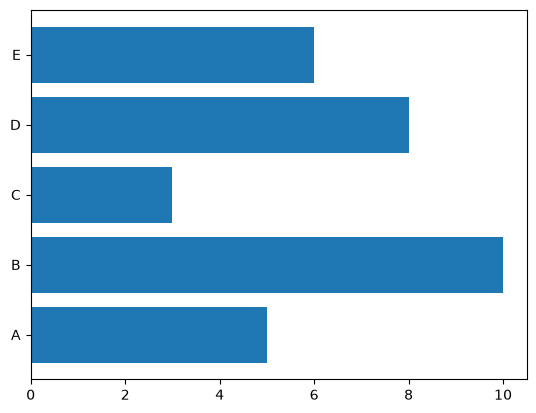

In [14]:
plt.barh(ctgy, val)

(array([ 23.,  68., 143., 229., 242., 157.,  96.,  35.,   3.,   4.]),
 array([-2.58672454, -1.9671791 , -1.34763367, -0.72808824, -0.1085428 ,
         0.51100263,  1.13054807,  1.7500935 ,  2.36963894,  2.98918437,
         3.6087298 ]),
 <BarContainer object of 10 artists>)

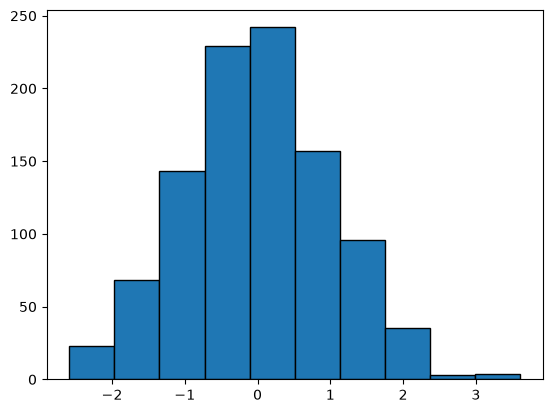

In [35]:
import numpy as np

data = np.random.randn(1000)

plt.hist(data, bins=10, edgecolor='black')

<Axes: >

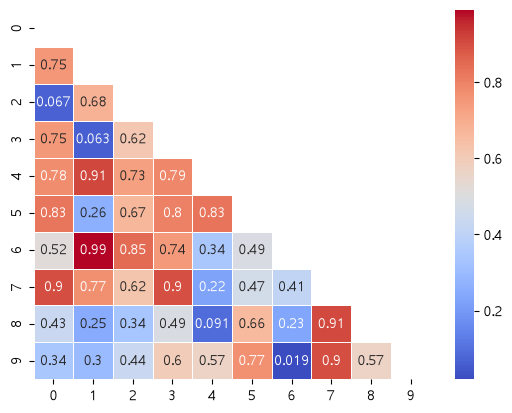

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = np.random.rand(10, 10)
mask = np.triu(np.ones_like(data, dtype=bool))

sns.heatmap(data, annot=True, mask=mask, cmap='coolwarm', linewidths=0.5)

C:\Users\EZ\AppData\Local\Temp\ipykernel_21496\96794129.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


<Axes: xlabel='day', ylabel='total_bill'>

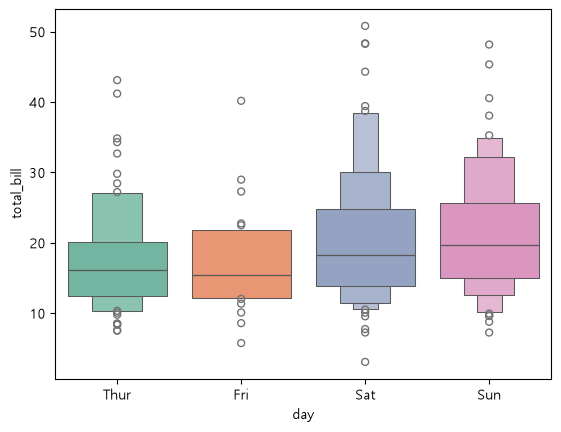

In [47]:
tips = sns.load_dataset('tips')

sns.boxenplot(
    x='day',
    y='total_bill',
    data=tips,
    palette='Set2'
)

C:\Users\EZ\AppData\Local\Temp\ipykernel_21496\1245893245.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


<Axes: xlabel='day', ylabel='total_bill'>

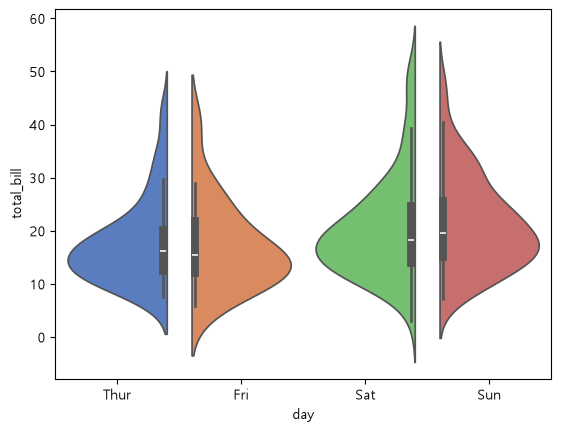

In [52]:
sns.violinplot(
    x='day',
    y='total_bill',
    data=tips,
    split=True,
    palette="muted"
)

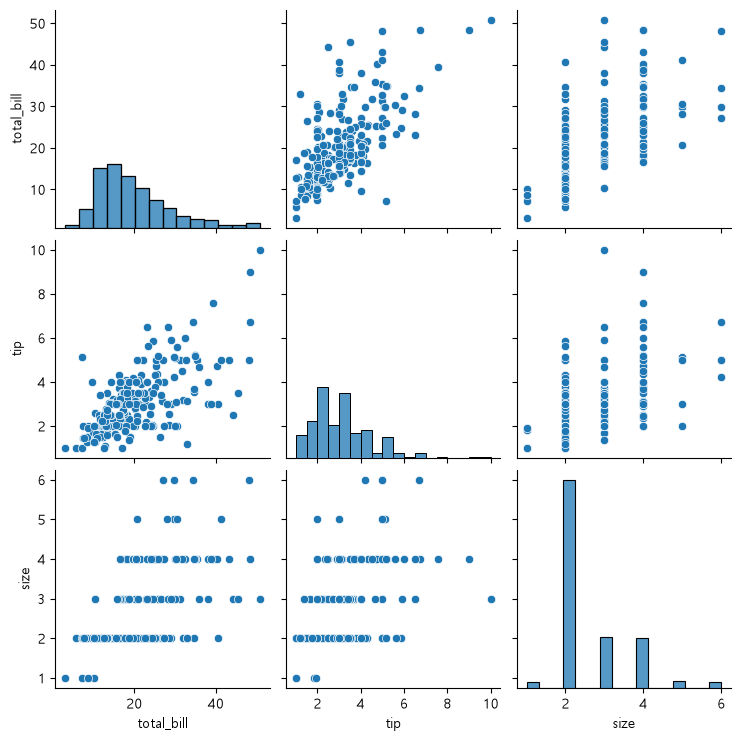

In [59]:
sns.pairplot(data=tips)

C:\Users\EZ\AppData\Local\Temp\ipykernel_21496\3899300720.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=types, palette='Set2')


<Axes: ylabel='count'>

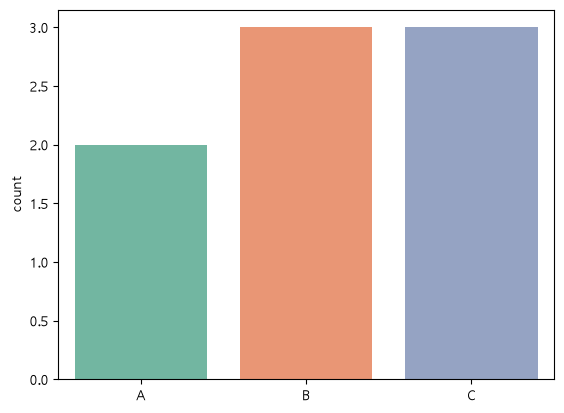

In [61]:
types = ['A', 'B', 'C', 'C', 'B', 'A', 'B', 'C']

sns.countplot(x=types, palette='Set2')

# 데이터의 그룹별 집계 & 피봇

In [62]:
data = {
'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
'Department': ['HR', 'IT', 'HR', 'IT', 'Finance'],
'Salary': [50000, 60000, 55000, 70000, 65000]
}

df = pd.DataFrame(data)
print(df)

      Name Department  Salary
0    Alice         HR   50000
1      Bob         IT   60000
2  Charlie         HR   55000
3    David         IT   70000
4      Eva    Finance   65000


In [63]:
df.groupby('Department')['Salary'].count()

Department
Finance    1
HR         2
IT         2
Name: Salary, dtype: int64

In [64]:
df.groupby('Department')['Salary'].sum()

Department
Finance     65000
HR         105000
IT         130000
Name: Salary, dtype: int64

In [65]:
df.groupby('Department')['Salary'].mean()

Department
Finance    65000.0
HR         52500.0
IT         65000.0
Name: Salary, dtype: float64

In [68]:
pivot_table = df.pivot_table(
    values='Salary', index='Department', aggfunc='mean'
)
print(pivot_table)

             Salary
Department         
Finance     65000.0
HR          52500.0
IT          65000.0


# 서울시에 위치하고 있는 스타벅스 매장 위치 분석

In [ ]:
import pandas as pd

df = pd.read_csv('data.csv', encoding='cp949', low_memory=False)  # 'cp949'는 한글 윈도우에서 사용하는 인코딩 방식

In [70]:
df.head()

,개방자치단체코드,관리번호,인허가일자,영업상태명,폐업일자,소재지면적,소재지우편번호,도로명우편번호,사업장명,업태구분명,...,월세액,위생업태명,전통업소주된음식,전통업소지정번호,전화번호,좌표정보(X),좌표정보(Y),지번주소,홈페이지,최종수정시점
0,3000000,3000000-104-2026-00072,2026-06-18,폐업,2026-06-20,3.30,110-809,3084.0,인스크립트,커피숍,...,NaN,커피숍,NaN,NaN,NaN,200257.115683,453485.120042,서울특별시 종로구 동숭동 1-5 서울문화재단 대학로,NaN,2026-06-21 04:15:08
1,3000000,3000000-104-2026-00073,2026-06-18,영업/정상,NaN,46.28,110-817,3022.0,부어크(Le Grand Bu'uk),커피숍,...,NaN,커피숍,NaN,NaN,NaN,196918.957999,454445.879757,서울특별시 종로구 부암동 251-2,NaN,2026-06-18 17:48:36
2,3000000,3000000-104-2026-00065,2026-06-04,영업/정상,NaN,17.52,110-840,3104.0,잇츠PC 창신점,기타 휴게음식점,...,NaN,기타 휴게음식점,NaN,NaN,NaN,201238.696068,452317.865597,서울특별시 종로구 창신동 292 원풍빌딩,NaN,2026-06-04 13:38:14
3,3000000,3000000-104-2023-00162,2023-12-12,영업/정상,NaN,56.39,110-530,3076.0,퍼프케이크하우스(Puff cake house),커피숍,...,NaN,커피숍,NaN,NaN,NaN,200076.008330,453827.307935,서울특별시 종로구 혜화동 70-1,NaN,2026-04-14 17:49:22
4,3000000,3000000-104-2026-00076,2026-06-23,영업/정상,NaN,45.70,110-773,3190.0,레드포스PC아레나 종각점,기타 휴게음식점,...,NaN,기타 휴게음식점,NaN,NaN,NaN,198696.792161,451962.682401,서울특별시 종로구 종로2가 75-9 미려빌딩,NaN,2026-06-23 12:00:27


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 642139 entries, 0 to 642138
Data columns (total 39 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   개방자치단체코드  642139 non-null  int64  
 1   관리번호      642139 non-null  str    
 2   인허가일자     642139 non-null  str    
 3   영업상태명     642139 non-null  str    
 4   폐업일자      443603 non-null  str    
 5   소재지면적     595529 non-null  str    
 6   소재지우편번호   518488 non-null  str    
 7   도로명우편번호   453823 non-null  float64
 8   사업장명      642139 non-null  str    
 9   업태구분명     642122 non-null  str    
 10  데이터갱신구분   642139 non-null  str    
 11  건물소유구분명   16 non-null      str    
 12  공장사무직직원수  4628 non-null    float64
 13  공장생산직직원수  4628 non-null    float64
 14  공장판매직직원수  4628 non-null    float64
 15  급수시설구분명   344363 non-null  str    
 16  남성종사자수    132112 non-null  float64
 17  다중이용업소여부  642137 non-null  str    
 18  데이터갱신시점   642139 non-null  str    
 19  도로명주소     496296 non-null  str    
 20  등급구분명     71213

In [73]:
print(list(df.columns))

['개방자치단체코드', '관리번호', '인허가일자', '영업상태명', '폐업일자', '소재지면적', '소재지우편번호', '도로명우편번호', '사업장명', '업태구분명', '데이터갱신구분', '건물소유구분명', '공장사무직직원수', '공장생산직직원수', '공장판매직직원수', '급수시설구분명', '남성종사자수', '다중이용업소여부', '데이터갱신시점', '도로명주소', '등급구분명', '보증액', '본사직원수', '상세영업상태명', '상세영업상태코드', '시설총규모', '여성종사자수', '영업상태코드', '영업장주변구분명', '월세액', '위생업태명', '전통업소주된음식', '전통업소지정번호', '전화번호', '좌표정보(X)', '좌표정보(Y)', '지번주소', '홈페이지', '최종수정시점']


In [74]:
df_1 = df[['영업상태명', '사업장명', '도로명주소']]
df_1

,영업상태명,사업장명,도로명주소
0,폐업,인스크립트,"서울특별시 종로구 동숭길 122, 서울문화재단 대학로 (동숭동)"
1,영업/정상,부어크(Le Grand Bu'uk),"서울특별시 종로구 창의문로3길 1, 2층 (부암동)"
2,영업/정상,잇츠PC 창신점,"서울특별시 종로구 종로 335, 원풍빌딩 지하1층 (창신동)"
3,영업/정상,퍼프케이크하우스(Puff cake house),"서울특별시 종로구 창경궁로35길 17, 1층 (혜화동)"
4,영업/정상,레드포스PC아레나 종각점,"서울특별시 종로구 종로 78, 미려빌딩 지하1층 (종로2가)"
...,...,...,...
642134,영업/정상,씨유서귀창천점,제주특별자치도 서귀포시 안덕면 일주서로 1357
642135,영업/정상,고근산김밥,"제주특별자치도 서귀포시 중산간동로 8370, 1층 (서호동)"
642136,영업/정상,지에스25성산신양점,"제주특별자치도 서귀포시 성산읍 섭지코지로26번길 6, 1호"
642137,영업/정상,지에스25서귀보영점,제주특별자치도 서귀포시 신동로67번길 24 (서호동)


In [76]:
df_2 = df_1.dropna(subset=['도로명주소'])
df_2

,영업상태명,사업장명,도로명주소
0,폐업,인스크립트,"서울특별시 종로구 동숭길 122, 서울문화재단 대학로 (동숭동)"
1,영업/정상,부어크(Le Grand Bu'uk),"서울특별시 종로구 창의문로3길 1, 2층 (부암동)"
2,영업/정상,잇츠PC 창신점,"서울특별시 종로구 종로 335, 원풍빌딩 지하1층 (창신동)"
3,영업/정상,퍼프케이크하우스(Puff cake house),"서울특별시 종로구 창경궁로35길 17, 1층 (혜화동)"
4,영업/정상,레드포스PC아레나 종각점,"서울특별시 종로구 종로 78, 미려빌딩 지하1층 (종로2가)"
...,...,...,...
642134,영업/정상,씨유서귀창천점,제주특별자치도 서귀포시 안덕면 일주서로 1357
642135,영업/정상,고근산김밥,"제주특별자치도 서귀포시 중산간동로 8370, 1층 (서호동)"
642136,영업/정상,지에스25성산신양점,"제주특별자치도 서귀포시 성산읍 섭지코지로26번길 6, 1호"
642137,영업/정상,지에스25서귀보영점,제주특별자치도 서귀포시 신동로67번길 24 (서호동)


In [77]:
df_3 = df_2[df_2['도로명주소'].str.contains('서울특별시')]
df_3

,영업상태명,사업장명,도로명주소
0,폐업,인스크립트,"서울특별시 종로구 동숭길 122, 서울문화재단 대학로 (동숭동)"
1,영업/정상,부어크(Le Grand Bu'uk),"서울특별시 종로구 창의문로3길 1, 2층 (부암동)"
2,영업/정상,잇츠PC 창신점,"서울특별시 종로구 종로 335, 원풍빌딩 지하1층 (창신동)"
3,영업/정상,퍼프케이크하우스(Puff cake house),"서울특별시 종로구 창경궁로35길 17, 1층 (혜화동)"
4,영업/정상,레드포스PC아레나 종각점,"서울특별시 종로구 종로 78, 미려빌딩 지하1층 (종로2가)"
...,...,...,...
146181,폐업,(주)참살이유통 한시적영업,"서울특별시 강동구 천호대로 1005, 현대백화점 지2층 (천호동)"
146183,영업/정상,메고지고무인떡카페 천호3동주민센터점,"서울특별시 강동구 진황도로23길 7, 1층 101호 (천호동)"
276006,폐업,쓰리팝(3 POP),"서울특별시 성동구 마조로 11, 지하1층 (행당동)"
319179,폐업,큰언니네부엌 사회적협동조합,"서울특별시 영등포구 양산로 190, 3층 (영등포동6가)"


In [78]:
df_4 = df_3[df_3['사업장명'].str.contains('스타벅스')]
df_4

,영업상태명,사업장명,도로명주소
14,영업/정상,스타벅스 광화문고려빌딩,"서울특별시 종로구 새문안로 91, 광화문 고려빌딩 2층 (신문로1가)"
21,영업/정상,스타벅스 광화문교보문고점,"서울특별시 종로구 종로 1, 교보생명빌딩 지하1층 (종로1가)"
57,영업/정상,스타벅스 성대입구점,"서울특별시 종로구 창경궁로 231-2, 1-2층 (명륜4가)"
127,영업/정상,스타벅스 강북삼성병원점,"서울특별시 종로구 새문안로 29, 강북삼성병원 C동 미래의학관4층 (평동)"
131,영업/정상,스타벅스 이마빌딩점,"서울특별시 종로구 종로1길 42 (수송동,지상1층)"
...,...,...,...
145419,영업/정상,스타벅스 상일동역점,"서울특별시 강동구 고덕로 399, 메가스퀘어동 1층 128,129,130,136호 ..."
145462,폐업,스타벅스커피 올림픽공원 북문점,"서울특별시 강동구 강동대로 171 (성내동, 현대토파즈 101호)"
145500,영업/정상,스타벅스 둔촌포레온스테이션5,"서울특별시 강동구 양재대로 1360, 포레온스테이션5 1층 1063,1064호 (둔촌동)"
145807,폐업,스타벅스 길동사거리점,서울특별시 강동구 양재대로 1441 (길동)


In [80]:
df_5 = df_4[df_4['영업상태명'] == '영업/정상']
df_5

,영업상태명,사업장명,도로명주소
14,영업/정상,스타벅스 광화문고려빌딩,"서울특별시 종로구 새문안로 91, 광화문 고려빌딩 2층 (신문로1가)"
21,영업/정상,스타벅스 광화문교보문고점,"서울특별시 종로구 종로 1, 교보생명빌딩 지하1층 (종로1가)"
57,영업/정상,스타벅스 성대입구점,"서울특별시 종로구 창경궁로 231-2, 1-2층 (명륜4가)"
127,영업/정상,스타벅스 강북삼성병원점,"서울특별시 종로구 새문안로 29, 강북삼성병원 C동 미래의학관4층 (평동)"
131,영업/정상,스타벅스 이마빌딩점,"서울특별시 종로구 종로1길 42 (수송동,지상1층)"
...,...,...,...
144317,영업/정상,스타벅스 천호사거리점,"서울특별시 강동구 올림픽로 651, 예경빌딩 1층 (천호동)"
144576,영업/정상,스타벅스 올림픽공원북2문점,"서울특별시 강동구 강동대로 199, 다성빌딩 1층 (성내동)"
145419,영업/정상,스타벅스 상일동역점,"서울특별시 강동구 고덕로 399, 메가스퀘어동 1층 128,129,130,136호 ..."
145500,영업/정상,스타벅스 둔촌포레온스테이션5,"서울특별시 강동구 양재대로 1360, 포레온스테이션5 1층 1063,1064호 (둔촌동)"


In [81]:
'서울특별시 종로구 종로1길 42 (수송동,지상1층)'.split()

['서울특별시', '종로구', '종로1길', '42', '(수송동,지상1층)']

In [83]:
df_5.loc[:, '시군구'] = df_5['도로명주소'].str.split().str[1]
df_5

,영업상태명,사업장명,도로명주소,시군구
14,영업/정상,스타벅스 광화문고려빌딩,"서울특별시 종로구 새문안로 91, 광화문 고려빌딩 2층 (신문로1가)",종로구
21,영업/정상,스타벅스 광화문교보문고점,"서울특별시 종로구 종로 1, 교보생명빌딩 지하1층 (종로1가)",종로구
57,영업/정상,스타벅스 성대입구점,"서울특별시 종로구 창경궁로 231-2, 1-2층 (명륜4가)",종로구
127,영업/정상,스타벅스 강북삼성병원점,"서울특별시 종로구 새문안로 29, 강북삼성병원 C동 미래의학관4층 (평동)",종로구
131,영업/정상,스타벅스 이마빌딩점,"서울특별시 종로구 종로1길 42 (수송동,지상1층)",종로구
...,...,...,...,...
144317,영업/정상,스타벅스 천호사거리점,"서울특별시 강동구 올림픽로 651, 예경빌딩 1층 (천호동)",강동구
144576,영업/정상,스타벅스 올림픽공원북2문점,"서울특별시 강동구 강동대로 199, 다성빌딩 1층 (성내동)",강동구
145419,영업/정상,스타벅스 상일동역점,"서울특별시 강동구 고덕로 399, 메가스퀘어동 1층 128,129,130,136호 ...",강동구
145500,영업/정상,스타벅스 둔촌포레온스테이션5,"서울특별시 강동구 양재대로 1360, 포레온스테이션5 1층 1063,1064호 (둔촌동)",강동구


In [84]:
df_6 = df_5.groupby('시군구').size().reset_index(name='사업장수')
df_6

,시군구,사업장수
0,강남구,100
1,강동구,21
2,강북구,7
3,강서구,35
4,관악구,17
5,광진구,23
6,구로구,13
7,금천구,15
8,노원구,15
9,도봉구,8


Text(0, 0.5, '사업장수')

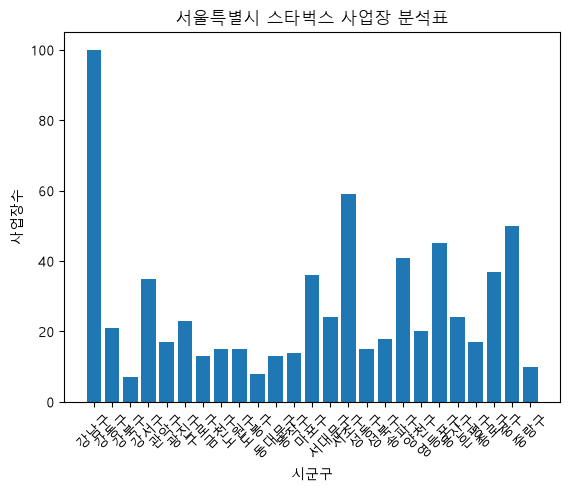

In [85]:
plt.bar(
    df_6['시군구'],
    df_6['사업장수']
)

plt.xticks(rotation=45)
plt.title('서울특별시 스타벅스 사업장 분석표')
plt.xlabel('시군구')
plt.ylabel('사업장수')